<a href="https://colab.research.google.com/github/adrianosima/Adriano_Simao/blob/main/C%C3%B3pia_de_C%C3%B3pia_de_Analise_data_set_unicornio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

%time

CPU times: user 2 µs, sys: 0 ns, total: 2 µs
Wall time: 6.44 µs


In [2]:
#Ler os dados
data_base = pd.read_csv('/content/unicorns till sep 2022.csv')

#verificar a dimensão do db
data_base.shape

(1186, 7)

In [3]:
#Verificar os 5 primeiros reginstros
data_base.head()

,Company,Valuation ($B),Date Joined,Country,City,Industry,Investors
0,ByteDance,$140,4/7/2017,China,Beijing,Artificial intelligence,"Sequoia Capital China, SIG Asia Investments, S..."
1,SpaceX,$127,12/1/2012,United States,Hawthorne,Other,"Founders Fund, Draper Fisher Jurvetson, Rothen..."
2,SHEIN,$100,7/3/2018,China,Shenzhen,E-commerce & direct-to-consumer,"Tiger Global Management, Sequoia Capital China..."
3,Stripe,$95,1/23/2014,United States,San Francisco,Fintech,"Khosla Ventures, LowercaseCapital, capitalG"
4,Canva,$40,1/8/2018,Australia,Surry Hills,Internet software & services,"Sequoia Capital China, Blackbird Ventures, Mat..."


In [4]:
#Renomeando colunas
data_base.rename(
    columns = {
        'Company': 'Empresa',
        'Valuation ($B)': 'Valor ($B)',
        'Date Joined': "Data de Adesão",
        'Country': "País",
        'City ': "Cidade",
       'Industry': "Industria",
        'Investors': "Investidores"
    }, inplace = True #Aplica as mudanças na base de origem
)

#verificar cada coluna
data_base.columns

Index(['Empresa', 'Valor ($B)', 'Data de Adesão', 'País', 'City ', 'Industria',
       'Investidores'],
      dtype='object')

In [5]:
#Verificando o tipo da informação
data_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1186 entries, 0 to 1185
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Empresa         1186 non-null   object
 1   Valor ($B)      1186 non-null   object
 2   Data de Adesão  1186 non-null   object
 3   País            1186 non-null   object
 4   City            1186 non-null   object
 5   Industria       1186 non-null   object
 6   Investidores    1168 non-null   object
dtypes: object(7)
memory usage: 65.0+ KB


In [6]:
#Verificando quantos e aonde estão localizados os campos nulos
data_base.isnull().sum()

,0
Empresa,0
Valor ($B),0
Data de Adesão,0
País,0
City,0
Industria,0
Investidores,18


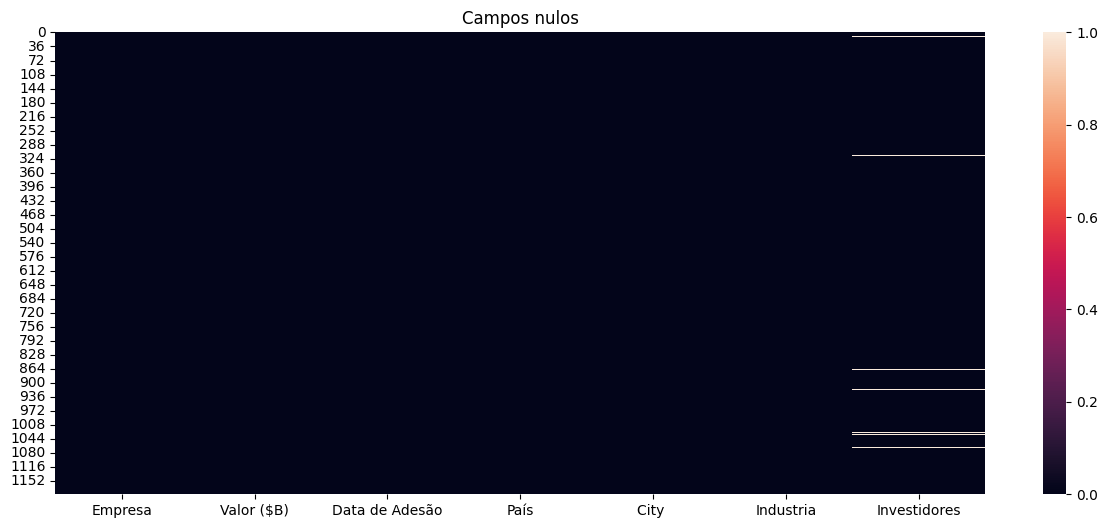

In [7]:
#Verificando de forma grafica
plt.figure(figsize=(15,6))
plt.title('Campos nulos')
sns.heatmap( data_base.isnull() );

In [8]:
#Verificando valores unicos

data_base.nunique()

,0
Empresa,1183
Valor ($B),222
Data de Adesão,695
País,48
City,286
Industria,34
Investidores,1152


In [9]:
#Verificando valores unicos em uma coluna
data_base['Industria'].unique()

array(['Artificial intelligence', 'Other',
       'E-commerce & direct-to-consumer', 'Fintech',
       'Internet software & services',
       'Supply chain, logistics, & delivery',
       'Data management & analytics',
       'Sequoia Capital, Thoma Bravo, Softbank', 'Edtech', 'Hardware',
       'Consumer & retail', 'Health', 'Auto & transportation',
       'Cybersecurity', 'Mobile & telecommunications', 'Travel',
       'Kuang-Chi',
       'Tiger Global Management, Tiger Brokers, DCM Ventures',
       'Jungle Ventures, Accel, Venture Highway',
       'Artificial Intelligence', 'GIC. Apis Partners, Insight Partners',
       'Vision Plus Capital, GSR Ventures, ZhenFund',
       'Hopu Investment Management, Boyu Capital, DC Thomson Ventures',
       'Internet', '500 Global, Rakuten Ventures, Golden Gate Ventures',
       'Sequoia Capital China, ING, Alibaba Entrepreneurs Fund',
       'Sequoia Capital China, Shunwei Capital Partners, Qualgro',
       'Dragonfly Captial, Qiming Venture Pa

In [10]:
#Valor unicos em rak
#comparando as startups que mais aparecem
data_base['Industria'].value_counts()

,count
Industria,
Fintech,239
Internet software & services,224
E-commerce & direct-to-consumer,103
Health,94
Artificial intelligence,74
Other,65
"Supply chain, logistics, & delivery",65
Cybersecurity,58
Data management & analytics,45


In [11]:
#Intervalos de startups unicornio

print(f" quase {0.201518+0.188870+0.079258+0.062395} das startups globais estão entre Fintech e Artificial intelligence")
data_base['Industria'].value_counts(normalize=True)

 quase 0.532041 das startups globais estão entre Fintech e Artificial intelligence


,proportion
Industria,
Fintech,0.201518
Internet software & services,0.188870
E-commerce & direct-to-consumer,0.086847
Health,0.079258
Artificial intelligence,0.062395
Other,0.054806
"Supply chain, logistics, & delivery",0.054806
Cybersecurity,0.048904
Data management & analytics,0.037943


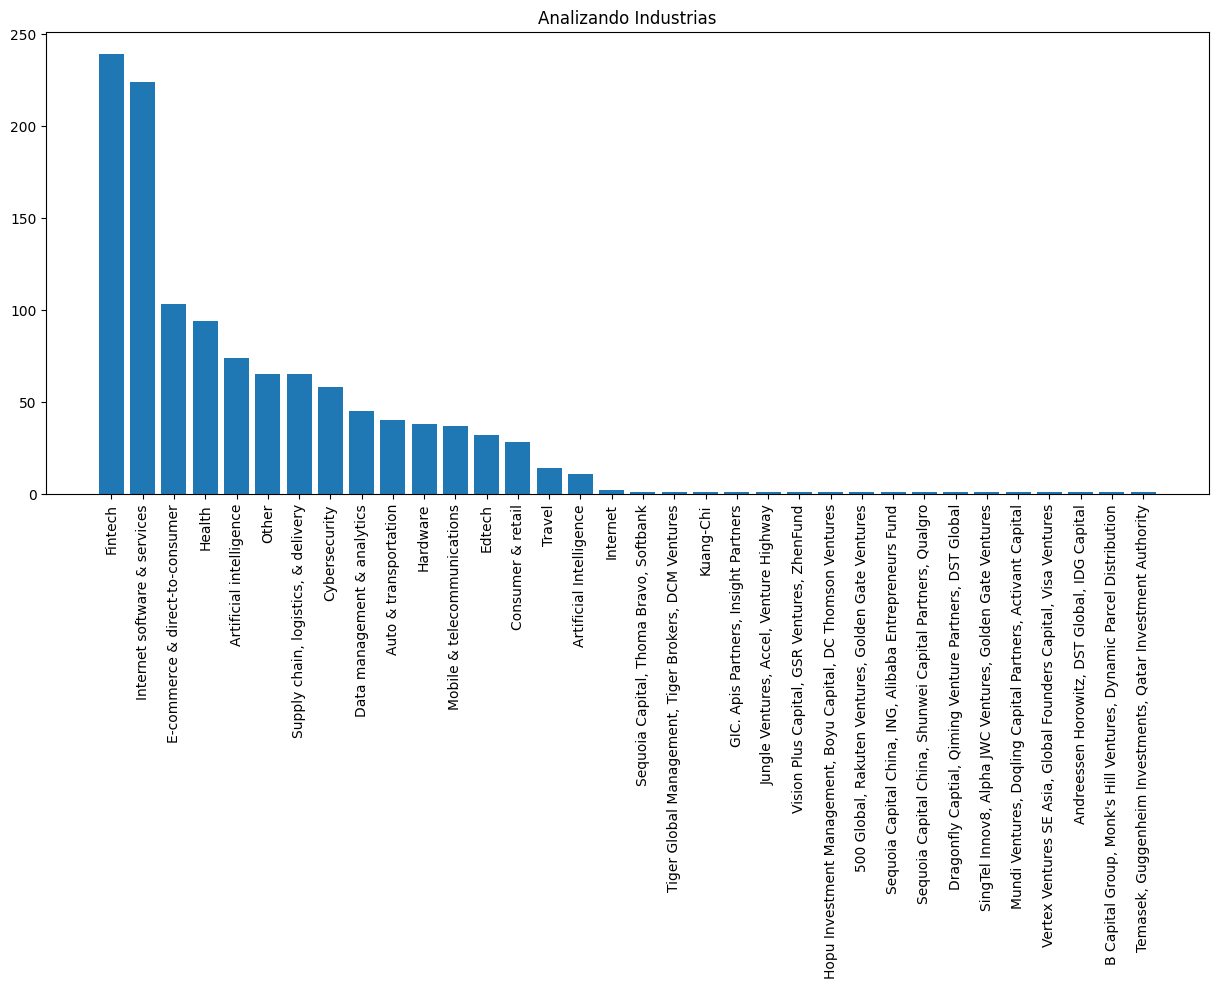

In [12]:
#tamanho e tema do grafico
plt.figure(figsize=(15,6))
plt.title("Analizando Industrias")

plt.bar(data_base['Industria'].value_counts().index, data_base['Industria'].value_counts())
plt.xticks(rotation=90);

#totacionar o index
#plt.xticks( rotation=45, ha='right' );

In [13]:
Analise = round((data_base['País'].value_counts(normalize=True))*100,1)

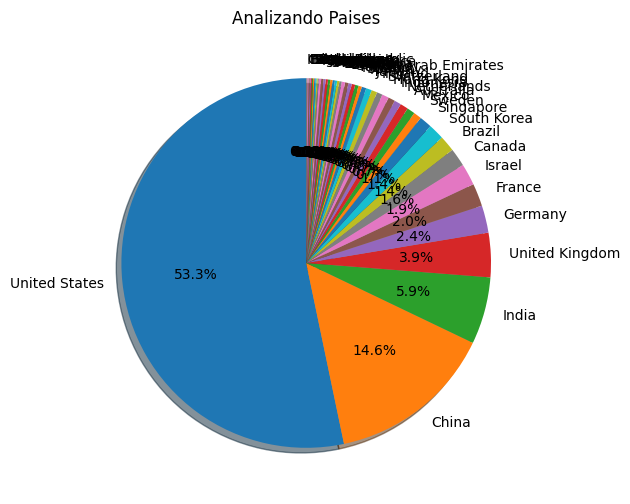

In [14]:
#plot geral dos paises

plt.figure(figsize=(15,6))
plt.title("Analizando Paises")

plt.pie(
    Analise,
    labels= Analise.index,
    shadow=True,
    startangle=90,
    autopct='%1.1f%%'
);

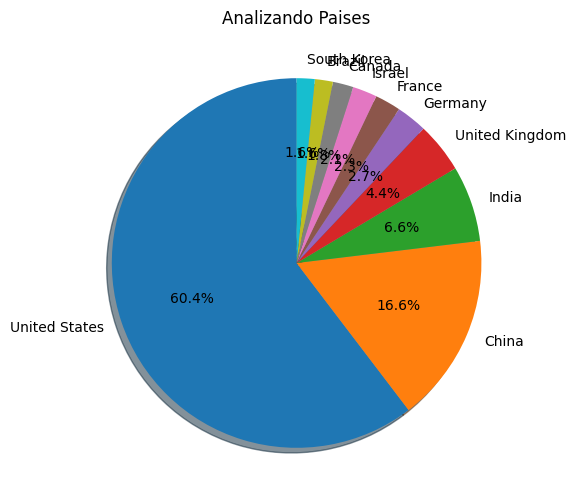

In [17]:
#plot top 10
plt.figure(figsize=(15,6))
plt.title("Analizando Paises")

plt.pie(
    Analise.head(10),
    labels= Analise.index[0:10],
    shadow=True,
    startangle=90,
    autopct='%1.1f%%'
);

In [20]:
#manipulação de tipos, tirando dada do formato objecto
data_base['Data de Adesão'] = pd.to_datetime(data_base['Data de Adesão'])
data_base['Data de Adesão']

,Data de Adesão
0,2017-04-07
1,2012-12-01
2,2018-07-03
3,2014-01-23
4,2018-01-08
...,...
1181,2022-06-21
1182,2022-06-21
1183,2022-07-05
1184,2022-07-12
